<style>
.jp-RenderedMarkdown, .rendered_html { font-family: Arial, Helvetica, sans-serif; font-size: 15px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 24px; font-weight: 700; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 20px; font-weight: 650; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 17px; font-weight: 600; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .rendered_html p, .rendered_html li { font-size: 15px; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 13px; }
</style>


# MeridianAI — Customer Segmentation

# Notebook 03 – Customer Segmentation using K-Means Clustering

## Objective

The objective of this notebook is to perform customer segmentation using the K-Means clustering algorithm.

Customer segmentation groups customers with similar purchasing behaviour based on Recency, Frequency, Monetary Value (RFM), and Customer Score.

The segmentation process helps businesses:

- Identify high-value customers
- Understand purchasing behaviour
- Personalize marketing campaigns
- Improve customer retention
- Support future machine learning models

The segmented customer dataset generated in this notebook will be further refined using advanced clustering techniques in the next notebook.

Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

LOAD PROCESSED CUSTOMER DATA

In [5]:
customer_df = pd.read_csv(
    "../data/processed/customer_features.csv"
)

In [6]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00,325,12,77556.46
1,12347.0,8,2967,4921.53,2011-12-07 15:52:00,1,8,4921.53
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00,74,5,2019.40
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00,18,4,4428.69
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,334.40


SEGMENTATION

In [7]:
X = customer_df[
    ['Recency', 'Frequency', 'Monetary']
]

# Feature Scaling

K-Means clustering relies on Euclidean distance. Since customer features are measured on different scales, StandardScaler is used to normalize all features before clustering.

This ensures that no single feature dominates the clustering process.

Scale the features (Normalization)

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

K-MEANS


# Finding the Optimal Number of Clusters

The Elbow Method is used to determine the most appropriate number of customer clusters.

The Within Cluster Sum of Squares (WCSS) is calculated for different values of K. The point where the reduction in WCSS begins to slow down indicates the optimal number of clusters.

In [9]:
wcss = []

In [10]:
for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

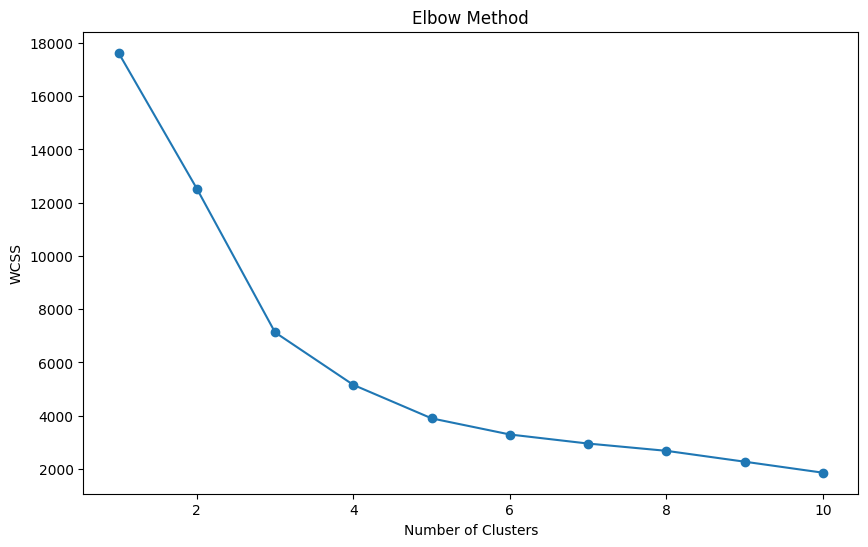

In [11]:
plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# Training the K-Means Model

The K-Means algorithm partitions customers into distinct groups based on purchasing behaviour.

Each customer is assigned to the nearest cluster centroid, minimizing the within-cluster variance.

In [12]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [13]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate,Recency,Frequency,Monetary,Cluster
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00,325,12,77556.46,1
1,12347.0,8,2967,4921.53,2011-12-07 15:52:00,1,8,4921.53,4
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00,74,5,2019.40,4
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00,18,4,4428.69,4
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,334.40,0


Evaluate Cluster Quality (silhouette Score)

In [14]:
score = silhouette_score(
    X_scaled,
    customer_df['Cluster']
)

print(score)

0.6005893012935021


# Customer Cluster Visualization

The generated customer clusters are visualized to understand the separation between customer groups and evaluate clustering quality.

These visualizations assist in identifying customer purchasing patterns and business opportunities.

Visualize Clusters

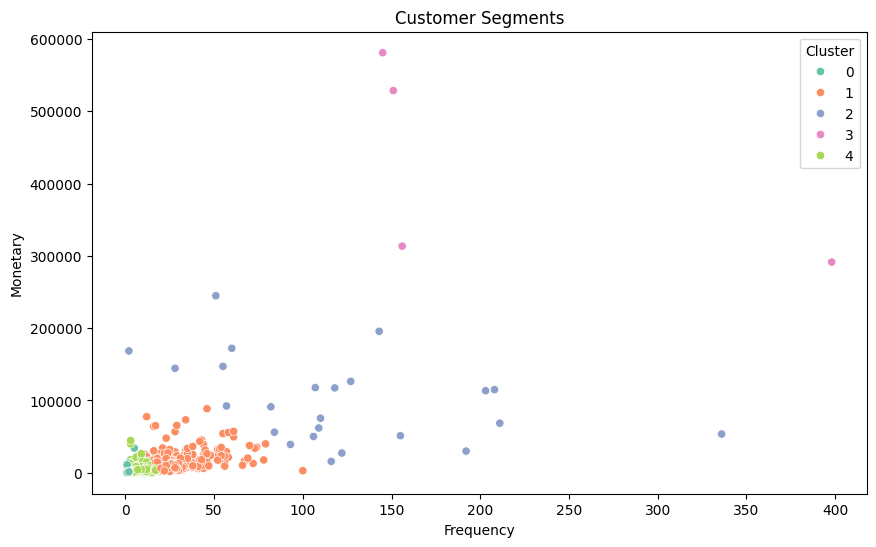

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=customer_df['Frequency'],
    y=customer_df['Monetary'],
    hue=customer_df['Cluster'],
    palette='Set2'
)

plt.title("Customer Segments")

plt.show()

# Cluster Analysis

Each cluster is analyzed using average customer metrics including:

- Recency
- Frequency
- Monetary Value
- Customer Score

This helps assign meaningful business interpretations to each customer segment.

In [17]:
fig = px.scatter_3d(
    customer_df,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    title='3D Customer Segmentation'
)

fig.show()

Test nbformat

In [16]:
import nbformat

print(nbformat.__version__)

5.10.4


Understand clusters
[ Note : Now pandas only calculate mean for R,F,M]

In [20]:
cluster_summary = customer_df.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,470.227439,2.166406,738.564065
1,27.055263,28.618421,13662.778166
2,21.458333,119.791667,98956.849250
3,2.500000,212.500000,428611.997500
4,74.674641,5.126935,1879.456482


Create Personas

In [21]:
persona_map = {
    0: "VIP Customers",
    1: "Churn Risk Customers",
    2: "Regular Customers",
    3: "Budget Buyers",
    4: "New Customers"
}

customer_df['Persona'] = customer_df['Cluster'].map(persona_map)

In [22]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate,Recency,Frequency,Monetary,Cluster,Persona
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00,325,12,77556.46,1,Churn Risk Customers
1,12347.0,8,2967,4921.53,2011-12-07 15:52:00,1,8,4921.53,4,New Customers
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00,74,5,2019.40,4,New Customers
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00,18,4,4428.69,4,New Customers
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,334.40,0,VIP Customers


SAVE SEGMENTED DATASET

In [23]:
customer_df.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

# Business Conclusion

Customer segmentation using K-Means successfully identified distinct groups of customers with different purchasing behaviours.

Key observations include:

- Premium customers exhibit high purchase frequency and spending.
- Regular customers contribute stable recurring revenue.
- Occasional customers purchase less frequently but remain valuable.
- Low-value customers present opportunities for targeted promotional campaigns.

The segmented customer dataset provides valuable business intelligence and serves as the foundation for advanced clustering, anomaly detection, churn prediction, recommendation systems, and sales forecasting in subsequent notebooks.